# Strain Analysis (multi-feed, slow-mo aware)

Loads a tracking CSV and:
1. Plots Δx vs **real** time (corrected for slow-motion playback if needed)
2. Detects **all** feed events and produces a filtered plot with every feed removed
3. Prints the measured distance of each feed
4. Prints the permanent strain (end of filtered curve − start of filtered curve)

Edit `CSV_PATH` and check `SLOWMO_FACTOR` in the first code cell, then run all cells.

In [7]:
# ====== EDIT THIS ======
CSV_PATH       = r"C:\Users\joaki\Desktop\DTU\Trelleborg\svend\strain_tracking_2026-05-22T07-57-40.csv"   # path to your CSV file (use r"..." for Windows paths)
EXPECTED_FEED  = 3.0                    # nominal feed distance, in the CSV's units
STABLE_WINDOW  = 0.1                    # seconds — averaging window for stable regions (in REAL time)
MIN_FEED_FRAC  = 0.3                    # ignore moves smaller than this fraction of EXPECTED_FEED

# --- Time correction ---
# The CSV's time column is computed from the video's playback timeline, not real time.
# Phones store slow-mo at ~30 fps playback even when the capture rate was higher,
# so the CSV time axis ends up stretched. Divide it back down by the slow-mo factor:
#   120 fps capture → 30 fps playback : SLOWMO_FACTOR = 4
#   240 fps capture → 30 fps playback : SLOWMO_FACTOR = 8
#   real-time video, no slow-mo       : SLOWMO_FACTOR = 1
#
# (Formally: SLOWMO_FACTOR = capture_fps / playback_fps_of_file)
SLOWMO_FACTOR  = 4
# =======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
# ---- Multi-feed detection ----
def detect_feeds(t, x, expected_feed=3.0, stable_window_s=0.3,
                 smooth_s=0.05, min_feed_fraction=0.5):
    """Return a chronologically-ordered list of feed events."""
    n = len(t)
    if n < 5:
        return []
    dt = float(np.median(np.diff(t)))
    smooth_n = max(3, int(smooth_s / dt))

    x_smooth = pd.Series(x).rolling(smooth_n, center=True, min_periods=1).mean().to_numpy()
    v = np.gradient(x_smooth, t)
    abs_v = np.abs(v)
    peak_v = float(np.max(abs_v))
    if peak_v == 0:
        return []
    threshold = 0.30 * peak_v
    moving = abs_v > threshold

    regions, i = [], 0
    while i < n:
        if moving[i]:
            j = i
            while j < n and moving[j]:
                j += 1
            regions.append((i, j - 1))
            i = j
        else:
            i += 1
    if not regions:
        return []

    min_disp = min_feed_fraction * abs(expected_feed)
    significant = [r for r in regions if abs(x[r[1]] - x[r[0]]) >= min_disp]
    significant.sort(key=lambda r: r[0])
    if not significant:
        return []

    win = max(3, int(stable_window_s / dt))
    feeds = []
    for k, (fs, fe) in enumerate(significant):
        prev_end   = significant[k - 1][1] if k > 0 else -1
        next_start = significant[k + 1][0] if k < len(significant) - 1 else n

        bs  = max(prev_end + 1, fs - win)
        be  = fs
        as_ = fe + 1
        ae  = min(next_start, fe + 1 + win)
        if be <= bs or ae <= as_:
            continue

        feeds.append({
            "feed_start":    fs, "feed_end": fe,
            "before_stable": float(np.mean(x[bs:be])),
            "after_stable":  float(np.mean(x[as_:ae])),
            "before_range":  (bs, be),
            "after_range":   (as_, ae),
        })
    return feeds

In [9]:
# ---- Load CSV and apply slow-mo time correction ----
df = pd.read_csv(CSV_PATH, comment="#")

dx_cols = [c for c in df.columns if c.startswith("dx_") and c != "dx_px"]
if dx_cols:
    dx_col = dx_cols[0]
elif "dx_px" in df.columns:
    dx_col = "dx_px"
    print("NOTE: no calibrated column found; using dx_px (pixels).")
else:
    raise ValueError(f"No dx_ column found. Columns: {list(df.columns)}")

unit  = dx_col.split("_", 1)[1]
t_raw = df["time_s"].to_numpy()
t     = t_raw / SLOWMO_FACTOR              # <-- the fix: real time, not playback time
x     = df[dx_col].to_numpy()

print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Using column: {dx_col}   (unit: {unit})")
print(f"CSV (playback) time range: {t_raw[0]:.3f} → {t_raw[-1]:.3f} s")
print(f"Real time range (÷ {SLOWMO_FACTOR}):    {t[0]:.3f} → {t[-1]:.3f} s")
print(f"  → If this doesn't match your real-life recording duration, adjust SLOWMO_FACTOR.")
print(f"Δx range:   {x.min():.3f} → {x.max():.3f} {unit}")

Loaded 4447 rows from C:\Users\joaki\Desktop\DTU\Trelleborg\svend\strain_tracking_2026-05-22T07-57-40.csv
Using column: dx_mm   (unit: mm)
CSV (playback) time range: 0.000 → 37.050 s
Real time range (÷ 4):    0.000 → 9.262 s
  → If this doesn't match your real-life recording duration, adjust SLOWMO_FACTOR.
Δx range:   -0.091 → 28.006 mm


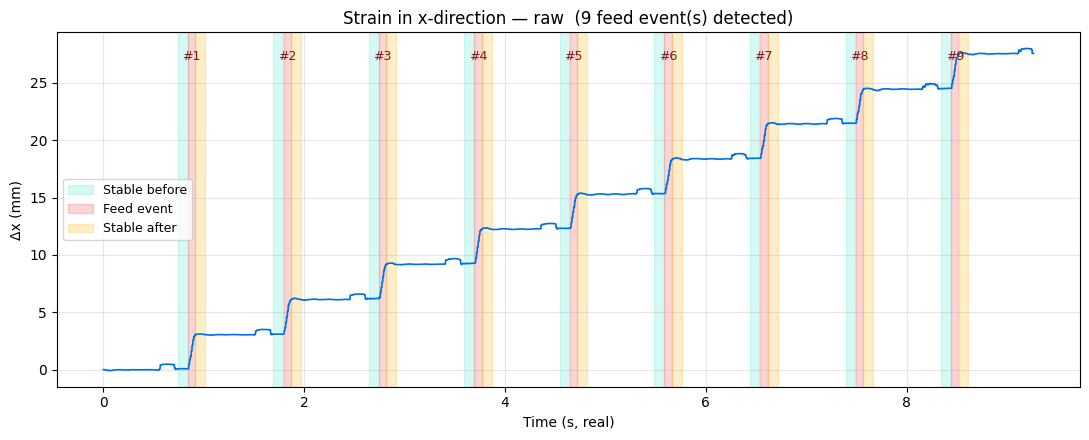

In [10]:
# ---- Plot 1: raw with all detected feed events highlighted ----
feeds = detect_feeds(t, x, expected_feed=EXPECTED_FEED,
                     stable_window_s=STABLE_WINDOW, min_feed_fraction=MIN_FEED_FRAC)

fig1, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(t, x, color="#0071e3", linewidth=1.2)
ax1.set_xlabel("Time (s, real)")
ax1.set_ylabel(f"Δx ({unit})")
ax1.set_title(f"Strain in x-direction — raw  ({len(feeds)} feed event(s) detected)")
ax1.grid(True, alpha=0.3)

for k, f in enumerate(feeds):
    bs, be = f["before_range"]
    as_, ae = f["after_range"]
    fs, fe = f["feed_start"], f["feed_end"]
    ax1.axvspan(t[bs], t[be - 1], color="#5eead4", alpha=0.25,
                label="Stable before" if k == 0 else None)
    ax1.axvspan(t[fs], t[fe],     color="#f87171", alpha=0.30,
                label="Feed event"    if k == 0 else None)
    ax1.axvspan(t[as_], t[ae - 1], color="#fbbf24", alpha=0.25,
                label="Stable after"  if k == 0 else None)
    yt = ax1.get_ylim()[1] - 0.05 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
    ax1.text((t[fs] + t[fe]) / 2, yt, f"#{k+1}",
             ha="center", va="top", fontsize=9, color="#7a1a1a")

if feeds:
    ax1.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

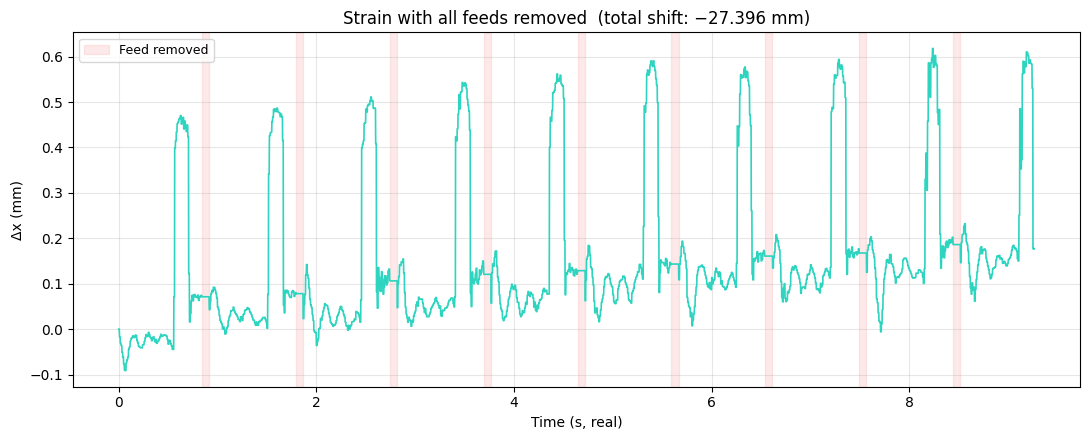

In [11]:
# ---- Build filtered signal (subtract every feed cumulatively) ----
x_filtered = x.copy()
cumulative_shift = 0.0
feed_distances = []

for f in feeds:
    feed_distance = f["after_stable"] - f["before_stable"]
    feed_distances.append(feed_distance)
    x_filtered[f["feed_end"] + 1:] -= feed_distance
    x_filtered[f["feed_start"]:f["feed_end"] + 1] = f["before_stable"] - cumulative_shift
    cumulative_shift += feed_distance

fig2, ax2 = plt.subplots(figsize=(11, 4.5))
ax2.plot(t, x_filtered, color="#2dd4bf", linewidth=1.2)
for k, f in enumerate(feeds):
    ax2.axvspan(t[f["feed_start"]], t[f["feed_end"]], color="#f87171", alpha=0.15,
                label="Feed removed" if k == 0 else None)
if feeds:
    ax2.legend(loc="best", fontsize=9)
ax2.set_xlabel("Time (s, real)")
ax2.set_ylabel(f"Δx ({unit})")
ax2.set_title(f"Strain with all feeds removed  (total shift: −{cumulative_shift:.3f} {unit})")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ---- Results ----
dt = float(np.median(np.diff(t)))
win = max(3, int(STABLE_WINDOW / dt))
first_stable     = float(np.mean(x_filtered[:win]))
last_stable      = float(np.mean(x_filtered[-win:]))
permanent_strain = last_stable - first_stable

bar = "─" * 70
print(bar)
print("  STRAIN ANALYSIS")
print(bar)
print(f"  Slow-mo factor applied:  {SLOWMO_FACTOR}")
print(f"  Real time range:         {t[0]:.3f} → {t[-1]:.3f} s")
print()
if feeds:
    print(f"  {len(feeds)} feed event(s) detected (expected ≈ {EXPECTED_FEED:+.3f} {unit} each)\n")
    print(f"  {'#':>3}  {'t_start':>8}  {'t_end':>8}  {'before':>10}  {'after':>10}  {'feed':>10}")
    for k, (f, d) in enumerate(zip(feeds, feed_distances), 1):
        fs, fe = f["feed_start"], f["feed_end"]
        print(f"  {k:>3}  {t[fs]:>8.3f}  {t[fe]:>8.3f}  "
              f"{f['before_stable']:>+10.4f}  {f['after_stable']:>+10.4f}  {d:>+10.4f}")
    print(f"\n  Sum of feed distances:   {sum(feed_distances):+.4f} {unit}")
else:
    print("  No feed events detected.")
print()
print(f"  First stable (filtered): {first_stable:+.4f} {unit}")
print(f"  Last  stable (filtered): {last_stable:+.4f} {unit}")
print(f"  Permanent strain:        {permanent_strain:+.4f} {unit}")
print(bar)

──────────────────────────────────────────────────────────────────────
  STRAIN ANALYSIS
──────────────────────────────────────────────────────────────────────
  Slow-mo factor applied:  4
  Real time range:         0.000 → 9.262 s

  9 feed event(s) detected (expected ≈ +3.000 mm each)

    #   t_start     t_end      before       after        feed
    1     0.842     0.915     +0.0713     +3.0839     +3.0126
    2     1.794     1.865     +3.0907     +6.1626     +3.0718
    3     2.744     2.817     +6.1906     +9.2413     +3.0507
    4     3.694     3.767     +9.2558    +12.3090     +3.0533
    5     4.644     4.719    +12.3171    +15.3324     +3.0152
    6     5.585     5.665    +15.3469    +18.4063     +3.0594
    7     6.535     6.615    +18.4238    +21.4782     +3.0544
    8     7.492     7.565    +21.4850    +24.4962     +3.0113
    9     8.442     8.515    +24.5148    +27.5822     +3.0673

  Sum of feed distances:   +27.3960 mm

  First stable (filtered): -0.0549 mm
  Last  stab